## 0. Environment Setup

In [1]:

# Run once. If this is a first install, restart the kernel afterward before continuing.
%pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121 --quiet
%pip install segmentation-models-pytorch albumentations pycocotools matplotlib scikit-learn thop --quiet


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:

import os
import json
import random
import time
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from pycocotools import mask as maskUtils
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM (GB):", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2))

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


Torch version: 2.14.0+cpu
CUDA available: False



## 1. Configuration

**Edit `RAW_IMAGES_DIR` and `COCO_JSON_PATH` below.**


In [4]:
# ---- EDIT THESE TWO PATHS ----
# ---- EDIT THESE TWO PATHS ----
RAW_IMAGES_DIR = Path("./banana-leaf-segmentation.coco-segmentation/train")
COCO_JSON_PATH = Path("./banana-leaf-segmentation.coco-segmentation/train/_annotations.coco.json")
# --------------------------------
# --------------------------------

WORK_DIR = Path("./stage2_work")
CACHE_DIR = WORK_DIR / "mask_cache"     # pre-decoded masks saved here (avoids re-decoding every epoch)
CHECKPOINT_DIR = WORK_DIR / "checkpoints"
OUTPUT_DIR = Path("./stage2_outputs")

for d in [WORK_DIR, CACHE_DIR, CHECKPOINT_DIR, OUTPUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 512          # resize target (source images are 640x640; 512 trims VRAM use with little detail loss)
BATCH_SIZE = 6          # segmentation is memory-heavier per image than detection; drop to 4 if you hit OOM
GRAD_ACCUM_STEPS = 2    # effective batch size = BATCH_SIZE * GRAD_ACCUM_STEPS = 12
ENCODER_NAME = "resnet34"
EPOCHS = 100
PATIENCE = 15
LR = 1e-4
WEIGHT_DECAY = 1e-4
WARMUP_EPOCHS = 5

# Category grouping — see Section 3 for the reasoning; change here if your intent differs
CATEGORY_MAP = {
    "leaf-boundary": "leaf",
    "affected-area": "affected",
    "banana-leaf-lesions": "affected",   # merged: same underlying concept, too few samples alone
    # "unhealthy_leaf" intentionally excluded — derived at inference time instead of predicted
}
CHANNEL_NAMES = ["leaf", "affected"]   # output channel order

assert RAW_IMAGES_DIR.exists(), f"Image folder not found: {RAW_IMAGES_DIR.resolve()}"
assert COCO_JSON_PATH.exists(), f"Annotation file not found: {COCO_JSON_PATH.resolve()}"

with open(COCO_JSON_PATH) as f:
    coco = json.load(f)

print(f"Loaded {len(coco['images'])} images, {len(coco['annotations'])} annotations, "
      f"{len(coco['categories'])} categories.")

Loaded 50 images, 161 annotations, 5 categories.



## 2. Data Exploration (EDA)

### 2.1 Category counts & co-occurrence


In [5]:

cat_id_to_name = {c["id"]: c["name"] for c in coco["categories"]}
print("Categories:", cat_id_to_name)

ann_counts = Counter(cat_id_to_name[a["category_id"]] for a in coco["annotations"])
print("\nAnnotation counts per category:")
for name, cnt in ann_counts.items():
    print(f"  {name}: {cnt}")

anns_by_image = defaultdict(list)
for a in coco["annotations"]:
    anns_by_image[a["image_id"]].append(a)

combo_counter = Counter(
    frozenset(cat_id_to_name[a["category_id"]] for a in anns)
    for anns in anns_by_image.values()
)
print("\nCategory combinations found per image:")
for combo, cnt in combo_counter.items():
    print(f"  {sorted(combo)}: {cnt} images")


Categories: {0: 'banana-leaf-lesions', 1: 'affected-area', 2: 'banana-leaf-lesions', 3: 'leaf-boundary', 4: 'unhealthy_leaf'}

Annotation counts per category:
  leaf-boundary: 53
  affected-area: 87
  unhealthy_leaf: 18
  banana-leaf-lesions: 3

Category combinations found per image:
  ['affected-area', 'leaf-boundary']: 33 images
  ['affected-area', 'leaf-boundary', 'unhealthy_leaf']: 12 images
  ['affected-area', 'banana-leaf-lesions', 'leaf-boundary']: 2 images
  ['leaf-boundary', 'unhealthy_leaf']: 1 images
  ['banana-leaf-lesions', 'leaf-boundary', 'unhealthy_leaf']: 1 images
  ['leaf-boundary']: 1 images


### 2.2 Verifying the nesting hypothesis (affected-area inside leaf-boundary)

In [6]:

def box_inside(inner, outer, tol=5):
    ix, iy, iw, ih = inner
    ox, oy, ow, oh = outer
    return (ix >= ox - tol and iy >= oy - tol and
            (ix + iw) <= (ox + ow + tol) and (iy + ih) <= (oy + oh + tol))

nested, total = 0, 0
for anns in anns_by_image.values():
    leaf_boxes = [a["bbox"] for a in anns if cat_id_to_name[a["category_id"]] == "leaf-boundary"]
    affected_boxes = [a["bbox"] for a in anns if cat_id_to_name[a["category_id"]] == "affected-area"]
    for ab in affected_boxes:
        total += 1
        if any(box_inside(ab, lb) for lb in leaf_boxes):
            nested += 1

print(f"affected-area boxes nested inside a leaf-boundary box: {nested}/{total} "
      f"({100*nested/total:.0f}%)")
print("--> confirms affected-area is a sub-region of the leaf, not an independent object.")


affected-area boxes nested inside a leaf-boundary box: 78/87 (90%)
--> confirms affected-area is a sub-region of the leaf, not an independent object.


### 2.3 Unified mask decoding (RLE + polygon) & visualization

Your annotations mix polygon-format and RLE-format segmentations across categories — the decoder below handles both transparently via `pycocotools`.

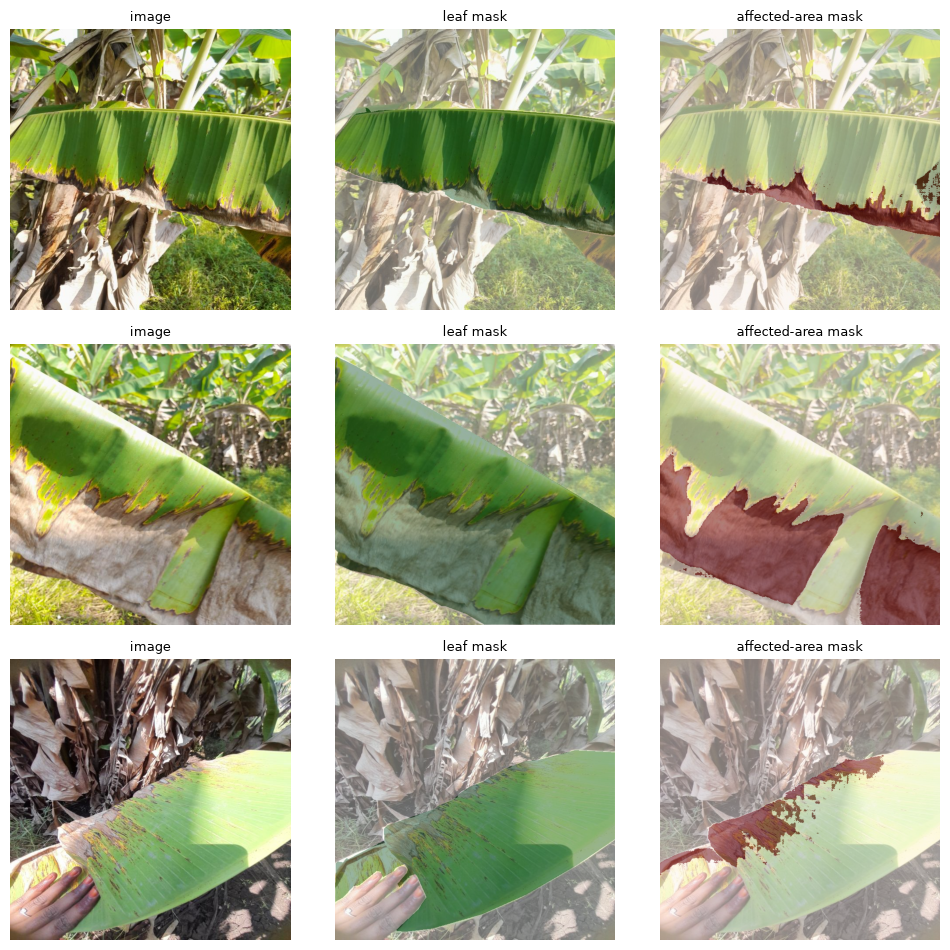

In [7]:

def decode_ann_mask(ann, h, w):
    seg = ann["segmentation"]
    if isinstance(seg, dict):  # RLE
        rle = maskUtils.frPyObjects(seg, h, w) if isinstance(seg["counts"], list) else seg
        return maskUtils.decode(rle)
    else:  # polygon(s)
        rles = maskUtils.frPyObjects(seg, h, w)
        return maskUtils.decode(maskUtils.merge(rles))

def build_channel_masks(image_id, h, w):
    # Returns dict: channel_name -> binary (h, w) uint8 mask, unioning all matching annotations.
    out = {name: np.zeros((h, w), dtype=np.uint8) for name in CHANNEL_NAMES}
    for a in anns_by_image.get(image_id, []):
        cat_name = cat_id_to_name[a["category_id"]]
        channel = CATEGORY_MAP.get(cat_name)
        if channel is None:
            continue
        m = decode_ann_mask(a, h, w)
        out[channel] = np.maximum(out[channel], m)
    return out

img_id_to_info = {img["id"]: img for img in coco["images"]}

def visualize_sample(image_id, ax_row):
    info = img_id_to_info[image_id]
    img_path = RAW_IMAGES_DIR / info["file_name"]
    if not img_path.exists():
        print(f"[skip] not found locally: {img_path}")
        return
    im = np.array(Image.open(img_path).convert("RGB"))
    masks = build_channel_masks(image_id, info["height"], info["width"])

    ax_row[0].imshow(im); ax_row[0].set_title("image", fontsize=9); ax_row[0].axis("off")
    ax_row[1].imshow(im); ax_row[1].imshow(masks["leaf"], alpha=0.4, cmap="Greens")
    ax_row[1].set_title("leaf mask", fontsize=9); ax_row[1].axis("off")
    ax_row[2].imshow(im); ax_row[2].imshow(masks["affected"], alpha=0.5, cmap="Reds")
    ax_row[2].set_title("affected-area mask", fontsize=9); ax_row[2].axis("off")

sample_ids = random.sample(list(anns_by_image.keys()), k=min(3, len(anns_by_image)))
fig, axes = plt.subplots(len(sample_ids), 3, figsize=(10, 3.2*len(sample_ids)))
if len(sample_ids) == 1:
    axes = axes[None, :]
for row, image_id in zip(axes, sample_ids):
    visualize_sample(image_id, row)
plt.tight_layout()
plt.show()



### 2.4 Pixel-level class balance

This directly drives the loss weighting in Section 5 — plain unweighted BCE would let the model
learn "predict all-background" for the affected-area channel and still show a deceptively low loss.


In [8]:

leaf_ratios, affected_ratios, affected_within_leaf = [], [], []
n_healthy = 0

for img in coco["images"]:
    h, w = img["height"], img["width"]
    masks = build_channel_masks(img["id"], h, w)
    leaf_px = masks["leaf"].sum()
    affected_px = masks["affected"].sum()
    leaf_ratios.append(leaf_px / (h * w))
    affected_ratios.append(affected_px / (h * w))
    if leaf_px > 0:
        affected_within_leaf.append(affected_px / leaf_px)
    if affected_px == 0:
        n_healthy += 1

print(f"Leaf pixel coverage:        mean={np.mean(leaf_ratios)*100:.1f}%  median={np.median(leaf_ratios)*100:.1f}%")
print(f"Affected coverage (of img): mean={np.mean(affected_ratios)*100:.2f}%  median={np.median(affected_ratios)*100:.2f}%")
print(f"Affected coverage (of leaf):mean={np.mean(affected_within_leaf)*100:.2f}%  median={np.median(affected_within_leaf)*100:.2f}%")
print(f"Fully healthy images (0 affected pixels): {n_healthy}/{len(coco['images'])}")

# These feed directly into BCE pos_weight in Section 5 — computed once here, reused later.
GLOBAL_LEAF_MEAN = np.mean(leaf_ratios)
GLOBAL_AFFECTED_MEAN = np.mean(affected_ratios)


Leaf pixel coverage:        mean=52.3%  median=51.8%
Affected coverage (of img): mean=7.51%  median=3.83%
Affected coverage (of leaf):mean=15.87%  median=10.23%
Fully healthy images (0 affected pixels): 2/50



## 3. Data Preprocessing

### 3.1 Train / val / test split

Unlike Stage 1, there's no augmentation-duplicate leakage risk here (verified: all 50 images map to
50 unique source photos). A plain random split is safe. The one wrinkle: only 2 images are fully
healthy, which is too few to stratify a 3-way split on (`sklearn` will error if you try) — so we
split randomly and explicitly report where the healthy images landed rather than silently ignoring it.


In [9]:

all_ids = [img["id"] for img in coco["images"]]
train_ids, temp_ids = train_test_split(all_ids, test_size=0.30, random_state=SEED)
val_ids, test_ids = train_test_split(temp_ids, test_size=0.50, random_state=SEED)

print(f"train={len(train_ids)}  val={len(val_ids)}  test={len(test_ids)}")

healthy_ids = [img["id"] for img in coco["images"]
               if build_channel_masks(img["id"], img["height"], img["width"])["affected"].sum() == 0]
for hid in healthy_ids:
    loc = "train" if hid in train_ids else ("val" if hid in val_ids else "test")
    print(f"Healthy image id={hid} landed in: {loc}")

print("\nNote: with only 2 healthy examples total, don't over-trust this model's behavior on fully "
      "healthy leaves yet — this is a real data gap, not something the training procedure can fix.")

split_map = {}
for i in train_ids: split_map[i] = "train"
for i in val_ids:   split_map[i] = "val"
for i in test_ids:  split_map[i] = "test"


train=35  val=7  test=8
Healthy image id=16 landed in: train
Healthy image id=41 landed in: train

Note: with only 2 healthy examples total, don't over-trust this model's behavior on fully healthy leaves yet — this is a real data gap, not something the training procedure can fix.


### 3.2 Cache decoded masks to disk

Decoding RLE/polygon masks on every training step would be wasted repeated work — we decode once here and cache as `.npy`, then the Dataset class just loads the cached array.

In [10]:

for img in coco["images"]:
    masks = build_channel_masks(img["id"], img["height"], img["width"])
    stacked = np.stack([masks[c] for c in CHANNEL_NAMES], axis=-1)  # (H, W, 2)
    np.save(CACHE_DIR / f"{img['id']}.npy", stacked)

print(f"Cached {len(coco['images'])} masks to {CACHE_DIR}")


Cached 50 masks to stage2_work\mask_cache


### 3.3 Augmentation pipeline (Albumentations)

Spatial transforms apply identically to image + mask; pixel-level transforms apply to the image only. MixUp/Mosaic (used in Stage 1) are detection/classification-oriented techniques and don't transfer cleanly to per-pixel masks, so we lean on spatial + pixel-level augmentation instead, which is the standard approach for segmentation.

In [11]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    # --- spatial ---
    A.HorizontalFlip(p=0.5),
    A.RandomRotate90(p=0.3),
    A.Affine(translate_percent=0.05, scale=(0.85, 1.15), rotate=(-20, 20), p=0.6, border_mode=cv2.BORDER_CONSTANT),
    A.RandomResizedCrop(size=(IMG_SIZE, IMG_SIZE), scale=(0.8, 1.0), p=0.4),
    # --- pixel-level ---
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=15, p=0.4),
    A.GaussianBlur(blur_limit=(3, 5), p=0.15),
    A.GaussNoise(std_range=(0.02, 0.08), p=0.15),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])


C:\Users\saugat\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 3.4 PyTorch Dataset & DataLoader

In [14]:
class LeafSegDataset(Dataset):
    def __init__(self, image_ids, transform):
        self.image_ids = image_ids
        self.transform = transform

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        info = img_id_to_info[image_id]
        img = np.array(Image.open(RAW_IMAGES_DIR / info["file_name"]).convert("RGB"))
        mask = np.load(CACHE_DIR / f"{image_id}.npy")  # (H, W, 2), values in {0,1}

        augmented = self.transform(image=img, mask=mask)
        img_t = augmented["image"]                       # (3, IMG_SIZE, IMG_SIZE) float, normalized
        mask_t = augmented["mask"].permute(2, 0, 1).float()  # (2, IMG_SIZE, IMG_SIZE)
        return img_t, mask_t

train_ds = LeafSegDataset(train_ids, train_transform)
val_ds = LeafSegDataset(val_ids, val_transform)
test_ds = LeafSegDataset(test_ids, val_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=0)

print(f"train batches: {len(train_loader)}  val batches: {len(val_loader)}  test images: {len(test_ds)}")

train batches: 5  val batches: 2  test images: 8


### 3.5 Sanity check: visualize an augmented training batch

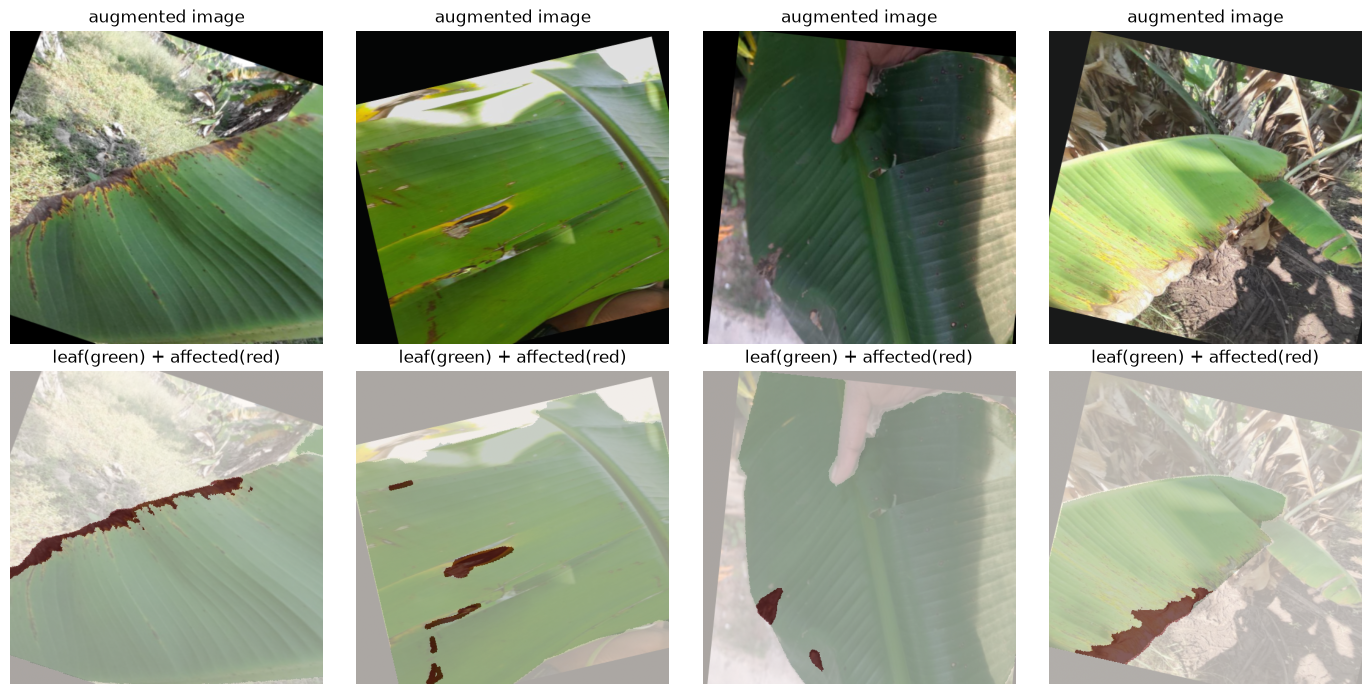

In [15]:

def denormalize(img_t):
    mean = np.array(IMAGENET_MEAN).reshape(3, 1, 1)
    std = np.array(IMAGENET_STD).reshape(3, 1, 1)
    img = img_t.numpy() * std + mean
    return np.clip(img.transpose(1, 2, 0), 0, 1)

imgs, masks = next(iter(train_loader))
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i in range(min(4, imgs.shape[0])):
    axes[0, i].imshow(denormalize(imgs[i]))
    axes[0, i].set_title("augmented image"); axes[0, i].axis("off")
    axes[1, i].imshow(denormalize(imgs[i]))
    axes[1, i].imshow(masks[i, 0], alpha=0.35, cmap="Greens")
    axes[1, i].imshow(masks[i, 1], alpha=0.5, cmap="Reds")
    axes[1, i].set_title("leaf(green) + affected(red)"); axes[1, i].axis("off")
plt.tight_layout()
plt.show()



## 4. Architecture

### Encoder tradeoffs (why ResNet34)

| Encoder | Params (approx.) | Notes |
|---|---|---|
| MobileNetV2 | ~3-4M | Lightest, fastest, some accuracy ceiling on fine lesion boundaries |
| **ResNet34** (chosen) | ~24M (full U-Net) | Good accuracy/speed balance; comfortably fits 4GB VRAM at `IMG_SIZE=512`, `batch=6` |
| EfficientNet-B0 | ~5-6M | Competitive accuracy at lower param count; good fallback if ResNet34 is tight on memory |

Switch via `ENCODER_NAME` in Section 1 if you hit CUDA OOM — try `"mobilenet_v2"` or
`"efficientnet-b0"` first before shrinking `IMG_SIZE` or `BATCH_SIZE` further.

**Decoder head:** standard U-Net decoder with skip connections from each encoder stage — lets the
model recover fine lesion boundaries that a pure encoder bottleneck would blur away.

**Output:** 2 channels (leaf, affected), raw logits (sigmoid applied inside the loss and at
inference, not baked into the model) — this is a **multi-label** setup (a pixel can belong to
"leaf" and "affected" simultaneously), which correctly reflects that affected-area is a subset of leaf,
not a competing class.


In [16]:

import segmentation_models_pytorch as smp
from thop import profile

device = "cuda" if torch.cuda.is_available() else "cpu"

model = smp.Unet(
    encoder_name=ENCODER_NAME,
    encoder_weights="imagenet",
    in_channels=3,
    classes=len(CHANNEL_NAMES),
    activation=None,   # raw logits; sigmoid applied in loss/eval
).to(device)

n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {n_params:,}")
print(f"Trainable parameters: {n_trainable:,}")

dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)
flops, _ = profile(model, inputs=(dummy,), verbose=False)
print(f"FLOPs (single {IMG_SIZE}x{IMG_SIZE} image): {flops/1e9:.2f} GFLOPs")


C:\Users\saugat\AppData\Roaming\Python\Python314\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\saugat\.cache\huggingface\hub\models--smp-hub--resnet34.imagenet. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Total parameters:     24,436,514
Trainable parameters: 24,436,514
FLOPs (single 512x512 image): 31.44 GFLOPs



## 5. Loss Function

**Dice loss** directly optimizes region overlap and is naturally robust to the class imbalance we
measured in Section 2.4 (affected-area ≈ 7.5% of image). **Weighted BCE** adds well-calibrated
per-pixel probabilities, which Dice alone doesn't guarantee. We combine both, and weight BCE's
`pos_weight` per channel using the actual pixel ratios measured from your data (not a guessed
constant).


In [17]:

def compute_pos_weight(mean_ratio):
    mean_ratio = np.clip(mean_ratio, 1e-4, 1 - 1e-4)
    return (1 - mean_ratio) / mean_ratio

pos_weights = torch.tensor([
    compute_pos_weight(GLOBAL_LEAF_MEAN),
    compute_pos_weight(GLOBAL_AFFECTED_MEAN),
], dtype=torch.float32).to(device)

print("Per-channel BCE pos_weight (leaf, affected):", pos_weights.tolist())

class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        probs = probs.flatten(2)      # (B, C, H*W)
        targets = targets.flatten(2)
        intersection = (probs * targets).sum(-1)
        union = probs.sum(-1) + targets.sum(-1)
        dice = (2 * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice.mean()

class ComboLoss(nn.Module):
    def __init__(self, pos_weight, bce_weight=0.5, dice_weight=0.5):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss(pos_weight=pos_weight.view(1, -1, 1, 1))
        self.dice = DiceLoss()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight

    def forward(self, logits, targets):
        return self.bce_weight * self.bce(logits, targets) + self.dice_weight * self.dice(logits, targets)

criterion = ComboLoss(pos_weights)


Per-channel BCE pos_weight (leaf, affected): [0.9135544300079346, 12.315276145935059]



## 6. Optimizer & Learning Rate Schedule

- **AdamW**, same rationale as Stage 1: faster convergence on small-dataset fine-tuning than SGD.
- **Linear warmup (5 epochs) → cosine annealing** via `SequentialLR`, avoiding instability from
  applying a full-strength LR to the pretrained encoder on step 1.
- **Mixed precision (AMP)** via `torch.cuda.amp` — cuts memory roughly in half, letting us keep
  `BATCH_SIZE=6` at `IMG_SIZE=512` on 4GB VRAM.
- **Gradient accumulation** (`GRAD_ACCUM_STEPS=2`) simulates an effective batch size of 12 without
  the memory cost of actually loading 12 images at once — if you still hit OOM, raise this instead
  of `BATCH_SIZE`.


In [18]:

from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

warmup_scheduler = LinearLR(optimizer, start_factor=0.1, total_iters=WARMUP_EPOCHS)
cosine_scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS - WARMUP_EPOCHS)
scheduler = SequentialLR(optimizer, schedulers=[warmup_scheduler, cosine_scheduler],
                          milestones=[WARMUP_EPOCHS])

scaler = torch.cuda.amp.GradScaler(enabled=(device == "cuda"))


C:\Users\saugat\AppData\Local\Temp\ipykernel_13800\1664614704.py:10: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device == "cuda"))



## 7. Training Loop

Regularization in play: `weight_decay` (above), heavy augmentation (Section 3.3) as the primary
defense against overfitting on only ~35 training images, and early stopping on validation Dice
(patience = 15 epochs) so we don't keep training past the point of diminishing returns.


In [19]:

def dice_score(logits, targets, threshold=0.5, eps=1e-7):
    probs = (torch.sigmoid(logits) > threshold).float()
    probs = probs.flatten(2)
    targets = targets.flatten(2)
    intersection = (probs * targets).sum(-1)
    union = probs.sum(-1) + targets.sum(-1)
    return ((2 * intersection + eps) / (union + eps)).mean(0)  # per-channel, averaged over batch

def run_epoch(loader, train_mode):
    model.train(train_mode)
    total_loss = 0.0
    total_dice = torch.zeros(len(CHANNEL_NAMES))
    n_batches = 0

    optimizer.zero_grad()
    for step, (imgs, masks) in enumerate(loader):
        imgs, masks = imgs.to(device), masks.to(device)

        with torch.cuda.amp.autocast(enabled=(device == "cuda")):
            logits = model(imgs)
            loss = criterion(logits, masks)
            if train_mode:
                loss = loss / GRAD_ACCUM_STEPS

        if train_mode:
            scaler.scale(loss).backward()
            if (step + 1) % GRAD_ACCUM_STEPS == 0:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
        else:
            with torch.no_grad():
                pass  # loss already computed above without grad tracking needed for logging

        total_loss += loss.item() * (GRAD_ACCUM_STEPS if train_mode else 1)
        total_dice += dice_score(logits.detach(), masks).cpu()
        n_batches += 1

    return total_loss / n_batches, (total_dice / n_batches).tolist()


In [20]:

history = {"train_loss": [], "val_loss": [], "val_dice_leaf": [], "val_dice_affected": []}
best_val_dice = -1
epochs_no_improve = 0
best_ckpt_path = CHECKPOINT_DIR / "best_model.pt"

for epoch in range(EPOCHS):
    train_loss, _ = run_epoch(train_loader, train_mode=True)
    with torch.no_grad():
        val_loss, val_dice = run_epoch(val_loader, train_mode=False)
    scheduler.step()

    mean_val_dice = float(np.mean(val_dice))
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_dice_leaf"].append(val_dice[0])
    history["val_dice_affected"].append(val_dice[1])

    print(f"Epoch {epoch+1:3d}/{EPOCHS} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
          f"val_dice[leaf]={val_dice[0]:.3f} val_dice[affected]={val_dice[1]:.3f} | "
          f"lr={optimizer.param_groups[0]['lr']:.2e}")

    if mean_val_dice > best_val_dice:
        best_val_dice = mean_val_dice
        epochs_no_improve = 0
        torch.save(model.state_dict(), best_ckpt_path)
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1} (no val Dice improvement for {PATIENCE} epochs).")
            break

print(f"\nBest mean validation Dice: {best_val_dice:.4f}  (checkpoint saved to {best_ckpt_path})")


C:\Users\saugat\AppData\Local\Temp\ipykernel_13800\2759577508.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device == "cuda")):


Epoch   1/100 | train_loss=0.8782 | val_loss=0.8553 | val_dice[leaf]=0.534 val_dice[affected]=0.130 | lr=2.80e-05
Epoch   2/100 | train_loss=0.8558 | val_loss=0.8436 | val_dice[leaf]=0.571 val_dice[affected]=0.125 | lr=4.60e-05
Epoch   3/100 | train_loss=0.8134 | val_loss=0.8326 | val_dice[leaf]=0.580 val_dice[affected]=0.142 | lr=6.40e-05
Epoch   4/100 | train_loss=0.7908 | val_loss=0.7979 | val_dice[leaf]=0.594 val_dice[affected]=0.181 | lr=8.20e-05
Epoch   5/100 | train_loss=0.7555 | val_loss=0.7491 | val_dice[leaf]=0.614 val_dice[affected]=0.216 | lr=1.00e-04
Epoch   6/100 | train_loss=0.7057 | val_loss=0.7047 | val_dice[leaf]=0.645 val_dice[affected]=0.239 | lr=1.00e-04
Epoch   7/100 | train_loss=0.6945 | val_loss=0.6799 | val_dice[leaf]=0.673 val_dice[affected]=0.254 | lr=9.99e-05
Epoch   8/100 | train_loss=0.6701 | val_loss=0.6633 | val_dice[leaf]=0.696 val_dice[affected]=0.275 | lr=9.98e-05
Epoch   9/100 | train_loss=0.6592 | val_loss=0.6437 | val_dice[leaf]=0.724 val_dice[affe

### 7.1 Training curves

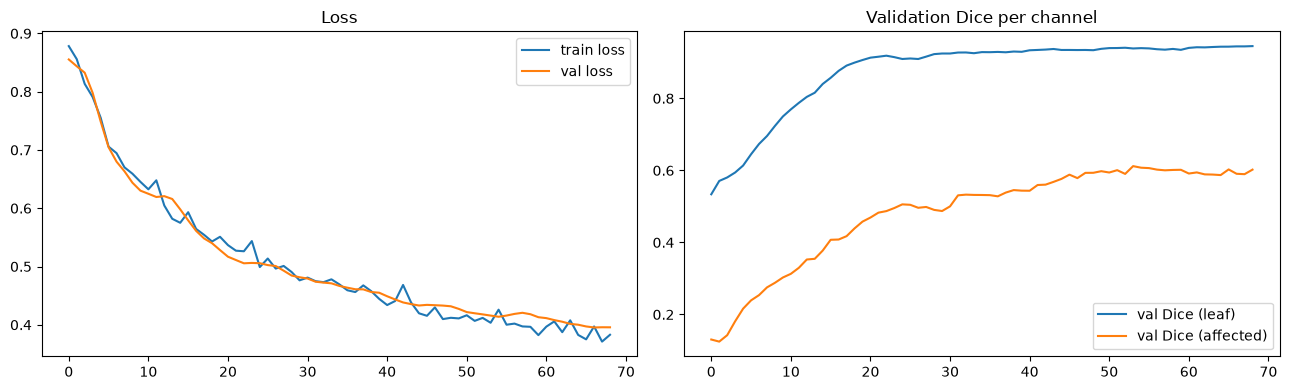

In [21]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history["train_loss"], label="train loss")
axes[0].plot(history["val_loss"], label="val loss")
axes[0].set_title("Loss"); axes[0].legend()
axes[1].plot(history["val_dice_leaf"], label="val Dice (leaf)")
axes[1].plot(history["val_dice_affected"], label="val Dice (affected)")
axes[1].set_title("Validation Dice per channel"); axes[1].legend()
plt.tight_layout()
plt.show()



## 8. Evaluation

### 8.1 Test-set metrics: IoU, Dice/F1, Precision, Recall (per channel)


In [22]:

model.load_state_dict(torch.load(best_ckpt_path))
model.eval()

def pixel_confusion(pred, target):
    tp = ((pred == 1) & (target == 1)).sum().item()
    fp = ((pred == 1) & (target == 0)).sum().item()
    fn = ((pred == 0) & (target == 1)).sum().item()
    tn = ((pred == 0) & (target == 0)).sum().item()
    return tp, fp, fn, tn

channel_stats = {name: {"tp": 0, "fp": 0, "fn": 0, "tn": 0} for name in CHANNEL_NAMES}

with torch.no_grad():
    for imgs, masks in test_loader:
        imgs = imgs.to(device)
        logits = model(imgs)
        preds = (torch.sigmoid(logits) > 0.5).float().cpu()
        for c, name in enumerate(CHANNEL_NAMES):
            tp, fp, fn, tn = pixel_confusion(preds[:, c], masks[:, c])
            channel_stats[name]["tp"] += tp
            channel_stats[name]["fp"] += fp
            channel_stats[name]["fn"] += fn
            channel_stats[name]["tn"] += tn

print(f"{'channel':<10} {'IoU':>7} {'Dice/F1':>9} {'Precision':>10} {'Recall':>8}")
for name in CHANNEL_NAMES:
    s = channel_stats[name]
    iou = s["tp"] / (s["tp"] + s["fp"] + s["fn"] + 1e-7)
    dice = 2 * s["tp"] / (2 * s["tp"] + s["fp"] + s["fn"] + 1e-7)
    precision = s["tp"] / (s["tp"] + s["fp"] + 1e-7)
    recall = s["tp"] / (s["tp"] + s["fn"] + 1e-7)
    print(f"{name:<10} {iou:7.3f} {dice:9.3f} {precision:10.3f} {recall:8.3f}")


channel        IoU   Dice/F1  Precision   Recall
leaf         0.885     0.939      0.912    0.968
affected     0.549     0.709      0.575    0.925



### 8.2 Threshold sweep for the `affected` channel

The 0.5 default binarization threshold isn't necessarily optimal, especially for the minority
`affected` channel — sweep it on the validation-derived predictions to find the IoU-maximizing cutoff.


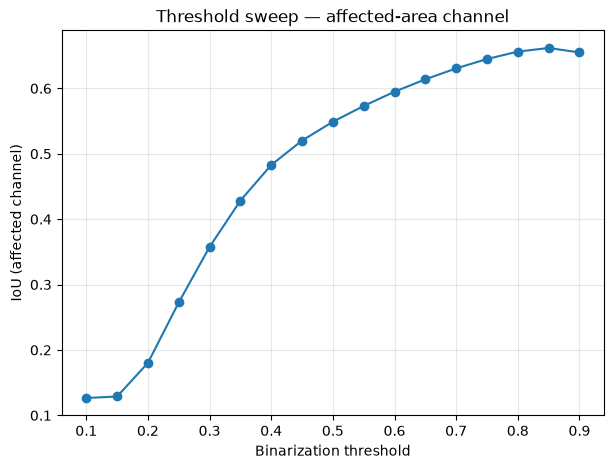

Best threshold for 'affected' channel: 0.85 (IoU=0.662)


In [23]:

thresholds = np.arange(0.1, 0.95, 0.05)
ious = []

with torch.no_grad():
    all_logits, all_targets = [], []
    for imgs, masks in test_loader:
        imgs = imgs.to(device)
        logits = model(imgs).cpu()
        all_logits.append(logits)
        all_targets.append(masks)
    all_logits = torch.cat(all_logits)
    all_targets = torch.cat(all_targets)

affected_idx = CHANNEL_NAMES.index("affected")
probs = torch.sigmoid(all_logits[:, affected_idx])
targets = all_targets[:, affected_idx]

for t in thresholds:
    pred = (probs > t).float()
    tp = ((pred == 1) & (targets == 1)).sum().item()
    fp = ((pred == 1) & (targets == 0)).sum().item()
    fn = ((pred == 0) & (targets == 1)).sum().item()
    iou = tp / (tp + fp + fn + 1e-7)
    ious.append(iou)

plt.figure(figsize=(7, 5))
plt.plot(thresholds, ious, marker="o")
plt.xlabel("Binarization threshold"); plt.ylabel("IoU (affected channel)")
plt.title("Threshold sweep — affected-area channel")
plt.grid(alpha=0.3)
plt.show()

best_t = thresholds[int(np.argmax(ious))]
print(f"Best threshold for 'affected' channel: {best_t:.2f} (IoU={max(ious):.3f})")


### 8.3 Pixel-level confusion matrix (affected-area channel)

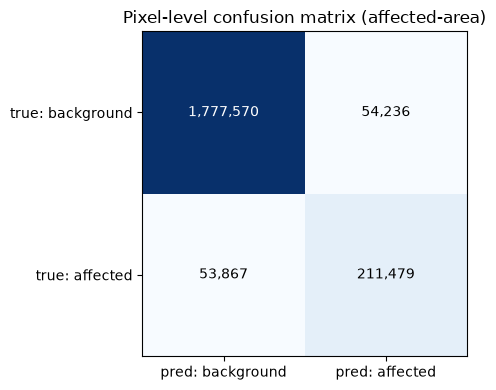

In [24]:

import itertools

pred_final = (probs > best_t).float().flatten().numpy().astype(int)
target_final = targets.flatten().numpy().astype(int)

cm = np.array([
    [((pred_final==0)&(target_final==0)).sum(), ((pred_final==1)&(target_final==0)).sum()],
    [((pred_final==0)&(target_final==1)).sum(), ((pred_final==1)&(target_final==1)).sum()],
])

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0,1]); ax.set_xticklabels(["pred: background", "pred: affected"])
ax.set_yticks([0,1]); ax.set_yticklabels(["true: background", "true: affected"])
for i, j in itertools.product(range(2), range(2)):
    ax.text(j, i, f"{cm[i,j]:,}", ha="center", va="center",
             color="white" if cm[i,j] > cm.max()/2 else "black")
ax.set_title("Pixel-level confusion matrix (affected-area)")
plt.tight_layout()
plt.show()


## 9. Inference Speed Profiling

In [25]:

sample_img, _ = test_ds[0]
sample_img = sample_img.unsqueeze(0).to(device)

for _ in range(5):
    with torch.no_grad():
        _ = model(sample_img)

n_runs = 30
if device == "cuda":
    torch.cuda.synchronize()
t0 = time.perf_counter()
for _ in range(n_runs):
    with torch.no_grad():
        _ = model(sample_img)
if device == "cuda":
    torch.cuda.synchronize()
elapsed = time.perf_counter() - t0

latency_ms = (elapsed / n_runs) * 1000
print(f"Device: {device}")
print(f"Avg latency: {latency_ms:.1f} ms/image  ({1000/latency_ms:.1f} FPS)")


Device: cpu
Avg latency: 229.7 ms/image  (4.4 FPS)



## 10. Edge-case / qualitative analysis

Showing the **worst-performing** test images (lowest Dice on the affected channel) — this is where
a model actually fails, which the aggregate metric in Section 8.1 can hide.


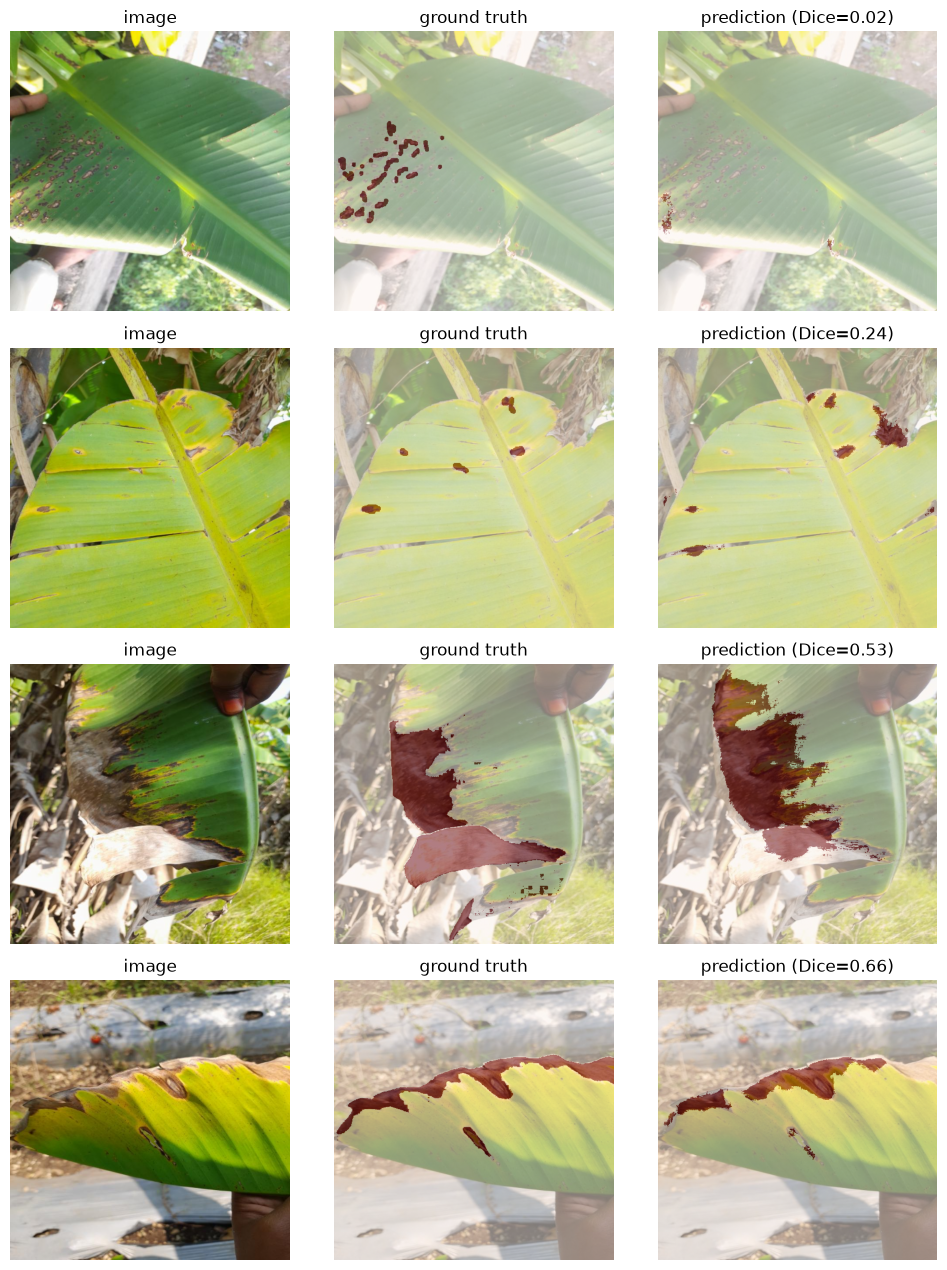

In [26]:

per_image_dice = []
with torch.no_grad():
    for i in range(len(test_ds)):
        img_t, mask_t = test_ds[i]
        logits = model(img_t.unsqueeze(0).to(device))
        pred = (torch.sigmoid(logits[0, affected_idx]) > best_t).float().cpu()
        target = mask_t[affected_idx]
        inter = (pred * target).sum().item()
        union = pred.sum().item() + target.sum().item()
        d = (2 * inter + 1e-7) / (union + 1e-7)
        per_image_dice.append((d, i))

per_image_dice.sort()
worst = per_image_dice[:4]

fig, axes = plt.subplots(len(worst), 3, figsize=(10, 3.2*len(worst)))
if len(worst) == 1:
    axes = axes[None, :]
for row, (dice_val, idx) in zip(axes, worst):
    img_t, mask_t = test_ds[idx]
    with torch.no_grad():
        logits = model(img_t.unsqueeze(0).to(device))
        pred = (torch.sigmoid(logits[0, affected_idx]) > best_t).float().cpu()

    img_disp = denormalize(img_t)
    row[0].imshow(img_disp); row[0].set_title("image"); row[0].axis("off")
    row[1].imshow(img_disp); row[1].imshow(mask_t[affected_idx], alpha=0.5, cmap="Reds")
    row[1].set_title("ground truth"); row[1].axis("off")
    row[2].imshow(img_disp); row[2].imshow(pred, alpha=0.5, cmap="Reds")
    row[2].set_title(f"prediction (Dice={dice_val:.2f})"); row[2].axis("off")
plt.tight_layout()
plt.show()



### Derived `unhealthy_leaf` flag (free, no extra model output needed)

Since `unhealthy_leaf` was redundant with "does the leaf contain affected-area pixels" (verified in
Section 2), we derive it at inference time instead of training a third output channel for it:


In [27]:

def is_unhealthy(logits, leaf_idx=0, affected_idx=1, leaf_thresh=0.5, affected_thresh=None):
    affected_thresh = affected_thresh if affected_thresh is not None else best_t
    leaf_mask = torch.sigmoid(logits[leaf_idx]) > leaf_thresh
    affected_mask = torch.sigmoid(logits[affected_idx]) > affected_thresh
    overlap = (leaf_mask & affected_mask).sum().item()
    return overlap > 0

with torch.no_grad():
    for i in range(min(5, len(test_ds))):
        img_t, _ = test_ds[i]
        logits = model(img_t.unsqueeze(0).to(device))[0].cpu()
        flag = is_unhealthy(logits)
        print(f"test image {i}: unhealthy={flag}")


test image 0: unhealthy=True
test image 1: unhealthy=True
test image 2: unhealthy=True
test image 3: unhealthy=True
test image 4: unhealthy=True



**Known limitations to flag:**
- Only 2/50 images are fully healthy — the model has seen almost no true-negative examples;
  don't trust its behavior on genuinely disease-free leaves until more such data exists.
- 50 images total is small for segmentation; expect some sensitivity to lighting/background
  conditions outside what's in this set (see Section 2's photos — mostly hand-held, outdoor, varied
  lighting, which is good diversity for the size, but still limited).
- `banana-leaf-lesions` (3 instances) was merged into `affected-area` on the assumption they're the
  same concept — revisit if that assumption turns out wrong.


## 11. Save model & next steps

In [28]:

import shutil
shutil.copy2(best_ckpt_path, OUTPUT_DIR / "banana_leaf_segmentation_best.pt")
print(f"Saved: {OUTPUT_DIR / 'banana_leaf_segmentation_best.pt'}")


Saved: stage2_outputs\banana_leaf_segmentation_best.pt
